# Many-Stats Tutorial: Population Genetics Analysis

This comprehensive tutorial demonstrates how to use many-stats for population genetics analysis, including both Python API and command-line interface usage.

## Table of Contents
1. [Installation](#installation)
2. [Python API Examples](#python-api-examples)
3. [Command-Line Interface Examples](#command-line-interface-examples)
4. [Advanced Usage with BED Masking](#advanced-usage-with-bed-masking)
5. [Statistical Analysis Examples](#statistical-analysis-examples)

## Installation

```bash
# Install many-stats in development mode
pip install -e .

# Install required dependencies
pip install bio2zarr  # Required for VCF loading
pip install matplotlib  # For plotting
pip install pandas  # For data manipulation
```


In [50]:
import pgstats as ms
import sgkit as sg
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pgstats.io.loaders import load_vcf_simple, check_bio2zarr_available

# Check if bio2zarr is available
if check_bio2zarr_available():
    print("✓ bio2zarr is available - VCF loading supported")
else:
    print("⚠ bio2zarr not available - install with: pip install bio2zarr")

# Simulate some genetic data for demonstration
ds = sg.simulate_genotype_call_dataset(n_variant=1000, n_sample=50, missing_pct=0.1)
print(f"Dataset shape: {ds.sizes}")
print(f"Available variables: {list(ds.data_vars.keys())}")
print(f"Available coordinates: {list(ds.coords.keys())}")

# For real VCF data, use:
# ds = load_vcf_simple("path/to/your/file.vcf.gz")


✓ bio2zarr is available - VCF loading supported
Dataset shape: Frozen({'contigs': 1, 'variants': 1000, 'alleles': 2, 'samples': 50, 'ploidy': 2})
Available variables: ['contig_id', 'variant_contig', 'variant_position', 'variant_allele', 'sample_id', 'call_genotype', 'call_genotype_mask']
Available coordinates: []


In [51]:
# Validate the dataset
validation_results = ms.utils.validate_dataset(ds)
print("Dataset validation:", validation_results)

# Check for missing data
missing_stats = ms.utils.check_missing_data(ds)
print("Missing data statistics:", missing_stats)


Dataset validation: {'valid': True, 'errors': [], 'warnings': ['Found 10082 missing genotypes'], 'info': {'missing_genotypes': 10082}}
Missing data statistics: {'total_missing': 10082, 'missing_per_variant': [12, 11, 11, 9, 7, 14, 13, 12, 10, 13, 8, 11, 9, 13, 11, 10, 10, 11, 14, 15, 11, 10, 10, 13, 11, 10, 9, 8, 13, 13, 8, 10, 10, 14, 10, 7, 10, 17, 13, 11, 14, 9, 7, 11, 13, 12, 12, 8, 7, 9, 14, 13, 9, 11, 14, 18, 9, 4, 9, 13, 9, 14, 15, 12, 11, 11, 11, 13, 6, 11, 8, 12, 11, 16, 7, 10, 5, 7, 7, 12, 16, 15, 7, 11, 4, 7, 10, 11, 9, 10, 6, 8, 9, 12, 10, 9, 4, 9, 14, 8, 10, 11, 12, 15, 8, 9, 9, 13, 11, 8, 8, 10, 18, 11, 8, 9, 15, 8, 10, 8, 11, 11, 16, 4, 10, 11, 19, 9, 11, 10, 9, 11, 10, 6, 9, 8, 12, 9, 11, 8, 9, 14, 14, 11, 13, 10, 8, 7, 17, 10, 8, 11, 11, 11, 12, 17, 11, 12, 5, 8, 7, 12, 10, 13, 7, 11, 9, 10, 6, 14, 13, 13, 6, 5, 8, 8, 12, 8, 13, 15, 11, 11, 9, 11, 15, 8, 7, 7, 10, 12, 9, 8, 12, 10, 9, 10, 8, 10, 8, 5, 7, 10, 12, 10, 7, 10, 13, 2, 13, 11, 12, 11, 9, 7, 16, 10, 6, 12, 10

## 3. Basic Statistical Analysis

### Site Frequency Spectrum (SFS) Statistics

**Note on Folded vs Unfolded SFS:**
- **Folded SFS**: Uses the minor allele frequency (MAF), treating derived and ancestral alleles symmetrically. Good when ancestral state is unknown.
- **Unfolded SFS**: Uses the derived allele frequency, requiring knowledge of ancestral state. More powerful when ancestral state is known.

The Fu and Li statistics have both folded (D*, F*) and unfolded (D, F) versions.


In [52]:
# Calculate basic SFS statistics
print("Calculating SFS statistics...")
print("Note: These are raw values. For per-site normalization, use windowing analysis.")

# Theta estimators
theta_pi = ms.stats.theta_pi(ds)
theta_w = ms.stats.theta_w(ds)
theta_h = ms.stats.theta_h(ds)
theta_l = ms.stats.theta_l(ds)

print(f"Theta π (nucleotide diversity): {theta_pi.theta_pi.values[0]:.6f}")
print(f"Watterson's theta: {theta_w.theta_w.values[0]:.6f}")
print(f"Fay and Wu's theta: {theta_h.theta_h.values[0]:.6f}")
print(f"Zeng's theta_L: {theta_l.theta_l.values[0]:.6f}")

# Neutrality tests
tajima_d = ms.stats.tajima_d(ds)
zeng_e = ms.stats.zeng_e(ds)

# Fu and Li statistics (folded SFS - default)
fu_li_d_folded = ms.stats.fu_li_d(ds, folded=True)
fu_li_f_folded = ms.stats.fu_li_f(ds, folded=True)

# Fu and Li statistics (unfolded SFS)
fu_li_d_unfolded = ms.stats.fu_li_d(ds, folded=False)
fu_li_f_unfolded = ms.stats.fu_li_f(ds, folded=False)

print(f"\nNeutrality tests:")
print(f"Tajima's D: {tajima_d.tajima_d.values[0]:.6f}")
print(f"Zeng's E: {zeng_e.zeng_e.values[0]:.6f}")

print(f"\nFu and Li statistics (folded SFS):")
print(f"Fu and Li's D*: {fu_li_d_folded.fu_li_d_star.values[0]:.6f}")
print(f"Fu and Li's F*: {fu_li_f_folded.fu_li_f_star.values[0]:.6f}")

print(f"\nFu and Li statistics (unfolded SFS):")
print(f"Fu and Li's D: {fu_li_d_unfolded.fu_li_d.values[0]:.6f}")
print(f"Fu and Li's F: {fu_li_f_unfolded.fu_li_f.values[0]:.6f}")


Calculating SFS statistics...
Note: These are raw values. For per-site normalization, use windowing analysis.
Theta π (nucleotide diversity): 0.245714
Watterson's theta: 0.223254
Fay and Wu's theta: 0.020000
Zeng's theta_L: 0.142857

Neutrality tests:
Tajima's D: 0.063864
Zeng's E: -0.150084

Fu and Li statistics (folded SFS):
Fu and Li's D*: 0.526338
Fu and Li's F*: 0.524664

Fu and Li statistics (unfolded SFS):
Fu and Li's D: 0.526338
Fu and Li's F: 0.524664


### Linkage Disequilibrium (LD) Statistics


In [53]:
# Calculate LD statistics
print("Calculating LD statistics...")

# Calculate LD matrix for first 10 variants
ld_matrix = ms.stats.calculate_ld_matrix(ds.isel(variants=slice(0, 10)))
print(f"LD matrix contains {len(ld_matrix.pairs)} variant pairs")
print(f"Available variables: {list(ld_matrix.data_vars.keys())}")

# Show first few LD values
if len(ld_matrix.pairs) > 0:
    print(f"\nFirst few LD values:")
    print(f"LD D: {ld_matrix.D.values[:3]}")
    print(f"LD D': {ld_matrix.D_prime.values[:3]}")
    print(f"LD r²: {ld_matrix.r_squared.values[:3]}")

# Calculate omega statistic for detecting hard sweeps
omega = ms.stats.omega_statistic(ds.isel(variants=slice(0, 20)), window_size=10)
print(f"\nOmega statistic: {omega.omega_statistic.values[0]:.6f}")


Calculating LD statistics...
LD matrix contains 45 variant pairs
Available variables: ['variant_i', 'variant_j', 'position_i', 'position_j', 'distance', 'D', 'D_prime', 'r_squared']

First few LD values:
LD D: [-0.01606561 -0.02468    -0.04480367]
LD D': [-0.07210177 -0.14517645 -0.18773107]
LD r²: [0.00420533 0.01038537 0.03344625]

Omega statistic: 1.731199


### Haplotype Statistics


In [54]:
# Calculate haplotype statistics
print("Calculating haplotype statistics...")

# Haplotype diversity
hap_div = ms.stats.haplotype_diversity(ds.isel(variants=slice(0, 10)))
print(f"Haplotype diversity: {hap_div.haplotype_diversity.values[0]:.6f}")

# Garud H statistics
garud_h = ms.stats.garud_h_statistics(ds.isel(variants=slice(0, 20)))
print(f"Garud H1: {garud_h.garud_h1.values[0]:.6f}")
print(f"Garud H12: {garud_h.garud_h12.values[0]:.6f}")
print(f"Garud H123: {garud_h.garud_h123.values[0]:.6f}")
print(f"Garud H2/H1: {garud_h.garud_h2_h1.values[0]:.6f}")


Calculating haplotype statistics...
Haplotype diversity: 0.977273
Garud H1: 0.547400
Garud H12: 0.788800
Garud H123: 1.000000
Garud H2/H1: 0.079101


## 4. Windowing Analysis

Windowing allows you to calculate statistics across genomic regions rather than the entire dataset.


In [55]:
# Create a GenomicDataset for windowing analysis
from pgstats.core.dataset import GenomicDataset, WindowConfig

# Example 1: Genome-wide analysis (default behavior)
print("=== Genome-wide Analysis ===")
print("Creating genome-wide window (no window_size specified)...")
gds_genome_wide = GenomicDataset(ds)  # Uses default WindowConfig (window_size=None)
gds_genome_wide.create_windows()
genome_wide_stats = gds_genome_wide.calculate_windowed_stats(
    stats=['theta_pi', 'theta_w', 'tajima_d']
)
print(f"Genome-wide results shape: {genome_wide_stats.sizes}")
print(f"Number of windows: {genome_wide_stats.sizes['windows']}")
print("Note: Single genome-wide window with normalized theta estimators")

# Example 2: Position-based windowing
print("\n=== Position-based Windowing ===")
print("Creating position-based windows...")
window_config = WindowConfig(window_size=100, step_size=50)
gds_windowed = GenomicDataset(ds, window_config=window_config)
gds_windowed.create_windows()
windowed_stats = gds_windowed.calculate_windowed_stats(
    stats=['theta_pi', 'theta_w', 'tajima_d']
)

print(f"Windowed results shape: {windowed_stats.sizes}")
print(f"Number of windows: {windowed_stats.sizes['windows']}")
print(f"Available statistics: {list(windowed_stats.data_vars.keys())}")

# Note about LD statistics
print("\nNote: LD statistics (ld_r_squared, ld_d, ld_d_prime) are calculated")
print("separately using calculate_ld_matrix() rather than in windowed analysis.")

# Display results for first few windows
print("\nFirst 5 windows:")
print(windowed_stats.isel(windows=slice(0, 5)).to_dataframe())


=== Genome-wide Analysis ===
Creating genome-wide window (no window_size specified)...
Creating genome-wide window
Created 1 windows
Filtered to 1 windows (removed 0 with <5 variants)
Genome-wide results shape: Frozen({'windows': 1, 'contigs': 1, 'variants': 1000, 'alleles': 2, 'samples': 50, 'ploidy': 2})
Number of windows: 1
Note: Single genome-wide window with normalized theta estimators

=== Position-based Windowing ===
Creating position-based windows...
Creating position-based windows with size 100
Created 20 windows
Filtered to 20 windows (removed 0 with <5 variants)
Windowed results shape: Frozen({'windows': 20, 'contigs': 1, 'variants': 1000, 'alleles': 2, 'samples': 50, 'ploidy': 2})
Number of windows: 20
Available statistics: ['window_contig', 'window_start', 'window_stop', 'contig_id', 'variant_contig', 'variant_position', 'variant_allele', 'sample_id', 'call_genotype', 'call_genotype_mask', 'theta_pi', 'theta_w', 'tajima_d']

Note: LD statistics (ld_r_squared, ld_d, ld_d_pr

## 5. Command-Line Interface Examples

The many-stats CLI provides a convenient way to run analyses from the command line.


### Basic CLI Usage

```bash
# Show help
many-stats --help

# Basic analysis with VCF file
many-stats stats input.vcf.gz --output results_basic.csv

# Analysis with specific statistics
many-stats stats input.vcf.gz --stats theta_pi theta_w tajima_d --output results_specific.csv

# Analysis with windowing
many-stats stats input.vcf.gz --window-size 10000 --step-size 5000 --output results_windowed.csv
```


### Advanced CLI Usage with BED Masking

```bash
# Analysis with BED masking (non-callable regions)
many-stats stats data.vcf.gz \
    --bed non_callable_regions.bed \
    --bed-format non_callable \
    --output results_masked.csv

# Analysis with callable regions BED file
many-stats stats data.vcf.gz \
    --bed callable_regions.bed \
    --bed-format callable \
    --output results_callable.csv

# Full analysis with all options
many-stats stats data.vcf.gz \
    --bed regions.bed \
    --bed-format non_callable \
    --stats theta_pi theta_w tajima_d \
    --window-size 10000 \
    --step-size 5000 \
    --output results_full.csv
```


## 6. Visualization Examples

Create plots to visualize your results.


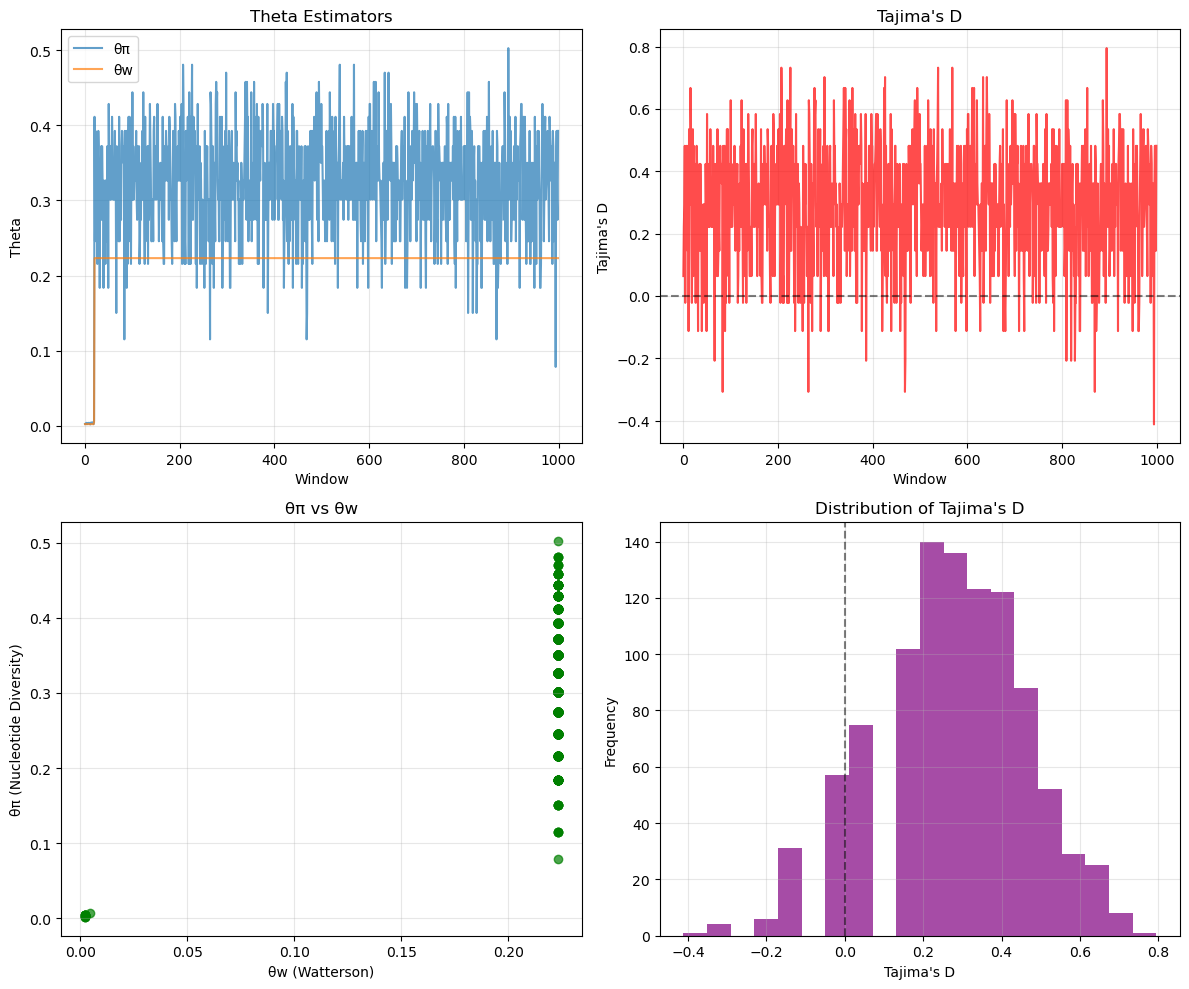

In [56]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot theta estimators
axes[0, 0].plot(windowed_stats.theta_pi.values, label='θπ', alpha=0.7)
axes[0, 0].plot(windowed_stats.theta_w.values, label='θw', alpha=0.7)
axes[0, 0].set_title('Theta Estimators')
axes[0, 0].set_xlabel('Window')
axes[0, 0].set_ylabel('Theta')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot Tajima's D
axes[0, 1].plot(windowed_stats.tajima_d.values, color='red', alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_title("Tajima's D")
axes[0, 1].set_xlabel('Window')
axes[0, 1].set_ylabel("Tajima's D")
axes[0, 1].grid(True, alpha=0.3)

# Plot theta_pi vs theta_w scatter
axes[1, 0].scatter(windowed_stats.theta_w.values, windowed_stats.theta_pi.values, 
                   color='green', alpha=0.7)
axes[1, 0].set_title('θπ vs θw')
axes[1, 0].set_xlabel('θw (Watterson)')
axes[1, 0].set_ylabel('θπ (Nucleotide Diversity)')
axes[1, 0].grid(True, alpha=0.3)

# Plot histogram of Tajima's D values
axes[1, 1].hist(windowed_stats.tajima_d.values, bins=20, alpha=0.7, color='purple')
axes[1, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title("Distribution of Tajima's D")
axes[1, 1].set_xlabel("Tajima's D")
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Advanced Usage with BED Masking

Demonstrate how to use BED files for callable site masking.


In [57]:
# Create a simple BED file for demonstration
import pandas as pd

# Create a BED file with some non-callable regions
bed_data = pd.DataFrame({
    'chrom': ['0', '0', '0'],
    'start': [200, 600, 800],
    'end': [300, 700, 900]
})

# Save BED file
bed_file = 'test_non_callable.bed'
bed_data.to_csv(bed_file, sep='\t', header=False, index=False)
print(f"Created BED file: {bed_file}")
print(bed_data)

# Create GenomicDataset with BED masking
from pgstats.core.dataset import CallableSitesConfig

gds_masked = GenomicDataset(ds, callable_config=CallableSitesConfig(
    bed_file=bed_file,
    bed_format='non_callable'
))

# Create windows and calculate windowed statistics with masking
print("\nCreating windows and calculating windowed statistics with BED masking...")
window_config = WindowConfig(window_size=100, step_size=50)
gds_masked_windowed = GenomicDataset(ds, 
                                   callable_config=CallableSitesConfig(
                                       bed_file=bed_file,
                                       bed_format='non_callable'
                                   ),
                                   window_config=window_config)
gds_masked_windowed.create_windows()
windowed_masked = gds_masked_windowed.calculate_windowed_stats(
    stats=['theta_pi', 'theta_w', 'tajima_d']
)

print(f"Windowed results with masking shape: {windowed_masked.sizes}")
print("\nFirst 5 windows with masking:")
print(windowed_masked.isel(windows=slice(0, 5)).to_dataframe())


Created BED file: test_non_callable.bed
  chrom  start  end
0     0    200  300
1     0    600  700
2     0    800  900
Masked 300 non-callable sites as missing data
Applied callable sites mask: 700 callable sites

Creating windows and calculating windowed statistics with BED masking...
Masked 300 non-callable sites as missing data
Applied callable sites mask: 700 callable sites
Creating position-based windows with size 100
Created 20 windows
Filtered to 20 windows (removed 0 with <5 variants)
Windowed results with masking shape: Frozen({'windows': 20, 'contigs': 1, 'variants': 1000, 'alleles': 2, 'samples': 50, 'ploidy': 2})

First 5 windows with masking:
                                                 window_contig  window_start  \
windows contigs variants alleles samples ploidy                                
0       0       0        0       0       0                   0             0   
                                         1                   0             0   
               

## 8. Summary

This tutorial demonstrated:

1. **Basic Setup**: Loading data and validating datasets
2. **SFS Statistics**: Theta estimators and neutrality tests
3. **LD Statistics**: Linkage disequilibrium measures and omega statistic
4. **Haplotype Statistics**: Diversity and Garud H statistics
5. **Windowing Analysis**: Calculating statistics across genomic regions
6. **CLI Usage**: Command-line interface for batch processing
7. **BED Masking**: Handling callable sites with BED files
8. **Visualization**: Creating plots to interpret results

### Next Steps

- Try the CLI with your own VCF files
- Experiment with different window sizes and statistics
- Use BED files to mask specific genomic regions
- Combine multiple statistics for comprehensive population genetics analysis

### Available Statistics

**SFS Statistics:**
- `theta_pi`, `theta_w`, `theta_h`, `theta_l`
- `tajima_d`, `zeng_e`
- `fu_li_d` (unfolded), `fu_li_f` (unfolded)
- `fu_li_d_star` (folded), `fu_li_f_star` (folded)

**LD Statistics:**
- `ld_d`, `ld_d_prime`, `ld_r_squared`, `omega_statistic`

**Haplotype Statistics:**
- `haplotype_diversity`, `garud_h1`, `garud_h12`, `garud_h123`, `garud_h2_h1`

For more information, see the [CLI Guide](../docs/CLI_GUIDE.md) and the [API documentation](../docs/API_REFERENCE.md).
